# Cancer Proteomics EDA + ML Classifier
**Dataset:** CPTAC Lung Adenocarcinoma (LUAD) — Clinical Proteomic Tumor Analysis Consortium  
**Goal:** Exploratory analysis of protein abundance → train a tumor vs. normal classifier → SHAP interpretability  

**Pipeline:**
1. Load CPTAC LUAD proteomics data
2. Preprocess: drop sparse columns, median impute
3. EDA: clustermap of top variable proteins
4. Train XGBoost classifier (tumor vs. normal)
5. Evaluate with ROC-AUC curve
6. SHAP beeswarm plot — identify top tumor-associated proteins

## 0. Install Dependencies

In [1]:
# Run once to install required packages
%pip install cptac scikit-learn xgboost shap matplotlib seaborn numpy pandas --quiet

Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  exit code: 1
  
  [85 lines of output]
  toml section missing WindowsPath('pyproject.toml') does not contain any of the tool sections: ['setuptools_scm', 'vcs-versioning']
  C:\Users\gelso\AppData\Local\Temp\pip-build-env-c_j_zu0j\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
  !!
  
          ********************************************************************************
          Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
  
          By 2027-Feb-18, you need to update your project and remove deprecated calls
          or your builds will no longer be supported.
  
          See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
          *************************************

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import cptac
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import shap

# Plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('All packages loaded successfully.')

All packages loaded successfully.


## 2. Download and Load CPTAC LUAD Data

CPTAC wraps the data fetch entirely — no manual download required.  
Lung adenocarcinoma (LUAD) dataset contains ~110 tumour samples + matched normals, with 8,000+ quantified proteins.

In [4]:
# Download dataset (first run only — cached afterwards)
cptac.download('luad')

TypeError: download() missing 3 required positional arguments: 'source', 'dtype', and 'data_file'

In [6]:
cptac.get_cancer_info()

{'brca': 'Breast invasive carcinoma',
 'ccrcc': 'Clear cell renal cell carcinoma',
 'coad': 'Colon adenocarcinoma',
 'gbm': 'Glioblastoma multiforme',
 'hnscc': 'Head and Neck squamous cell carcinoma',
 'lscc': 'Lung squamous cell carcinoma',
 'luad': 'Lung adenocarcinoma',
 'ov': 'Ovarian serous cystadenocarcinoma',
 'pda': 'Pancreatic ductal adenocarcinoma',
 'pdac': 'Pancreatic ductal adenocarcinoma',
 'ucec': 'Uterine Corpus Endometrial Carcinoma'}

In [7]:
luad = cptac.Luad() 

In [9]:
# Load LUAD dataset
luad = cptac.Luad()

# # Retrieve proteomics abundance table
# prot = luad.get_proteomics()
# print(f'Proteomics matrix shape: {prot.shape}')
# prot.head(3)

# optional but safer
print(luad.list_data_sources())

prot = luad.get_proteomics(source='umich')  # explicitly set source
prot.head()

              Data type    Available sources
0                   CNV         [bcm, washu]
1          circular_RNA                [bcm]
2                 miRNA         [bcm, washu]
3     phosphoproteomics         [bcm, umich]
4            proteomics         [bcm, umich]
5       transcriptomics  [bcm, broad, washu]
6   ancestry_prediction         [harmonized]
7      somatic_mutation  [harmonized, washu]
8              clinical               [mssm]
9             follow-up               [mssm]
10      medical_history               [mssm]
11     acetylproteomics              [umich]
12            cibersort              [washu]
13           hla_typing              [washu]
14         tumor_purity              [washu]
15                xcell              [washu]


Name,ARF5,M6PR,ESRRA,FKBP4,NDUFAF7,FUCA2,HS3ST1,SEMA3F,CFTR,CYP51A1,...,GBF1,CTNND1,WIZ,LDB1,WIZ,TSGA10,RFX7,SWSAP1,TUG1,SVIL
Database_ID,ENSP00000000233.5,ENSP00000000412.3,ENSP00000000442.6,ENSP00000001008.4,ENSP00000002125.4,ENSP00000002165.5,ENSP00000002596.5,ENSP00000002829.3,ENSP00000003084.6,ENSP00000003100.8,...,ENSP00000501064.1,ENSP00000501126.1,ENSP00000501256.3,ENSP00000501277.1,ENSP00000501300.1,ENSP00000501312.1,ENSP00000501317.1,ENSP00000501355.1,ENSP00000501406.1,ENSP00000501521.1
Patient_ID,,,,,,,,,,,,,,,,,,,,,
11LU013,0.786285,-0.332452,-0.008182,0.664553,-0.083248,0.717903,0.395759,NaN,-1.204550,0.387524,...,0.246809,0.461351,-0.553253,-0.122195,0.138115,-0.974209,-0.120763,NaN,-0.644736,NaN
11LU016,0.768472,-0.403172,0.726123,-0.146830,0.002308,0.487517,1.262676,-0.498287,-0.570044,-0.258518,...,-0.030711,0.272718,0.488027,-0.320011,0.212130,-0.842905,0.095945,NaN,NaN,NaN
11LU022,0.252194,-0.114091,0.106217,0.647038,0.023058,-0.057407,-0.121067,-0.396348,-1.024969,-0.941190,...,0.165939,-0.210486,-0.334806,-0.246996,0.219102,NaN,-0.299151,NaN,NaN,NaN
11LU035,0.686262,-0.137407,-0.570236,0.187284,0.006600,0.463262,-0.037442,NaN,-0.789793,-0.639767,...,0.139759,-0.007299,NaN,-0.590554,0.060887,-1.672911,-0.355487,NaN,NaN,NaN
C3L-00001,-0.013909,-0.007751,-0.171399,0.473614,-0.132759,0.242113,-0.880477,-0.570674,NaN,-0.205331,...,0.363547,-0.396643,1.158235,-0.238417,0.194351,-0.864266,-0.674254,NaN,NaN,NaN


## 3. Preprocessing

- Collapse multi-level column headers if present
- Drop proteins missing in >20% of samples
- Median impute remaining NaNs
- Extract tumour / normal labels from the sample index

In [10]:
# Flatten MultiIndex columns if present
if isinstance(prot.columns, pd.MultiIndex):
    prot.columns = ['_'.join(filter(None, map(str, c))).strip() for c in prot.columns]

# Keep only numeric columns
prot = prot.select_dtypes(include=[np.number])

# Drop proteins with >20% missing values
threshold = 0.20
prot = prot.loc[:, prot.isnull().mean() < threshold]
print(f'After dropping sparse proteins: {prot.shape}')

# Median impute
prot = prot.fillna(prot.median())
print(f'Missing values after imputation: {prot.isnull().sum().sum()}')

After dropping sparse proteins: (213, 9619)
Missing values after imputation: 0


In [11]:
# Extract class labels from sample index
# CPTAC sample IDs: tumour samples end in '.T', normals end in '.N'
def extract_label(sample_id: str) -> str:
    sid = str(sample_id).upper()
    if sid.endswith('.N') or 'NORMAL' in sid or 'NAT' in sid:
        return 'Normal'
    return 'Tumor'

labels = prot.index.get_level_values(0) if isinstance(prot.index, pd.MultiIndex) else prot.index
y_str = np.array([extract_label(s) for s in labels])

# Binary encode: Tumor=1, Normal=0
le = LabelEncoder()
y = le.fit_transform(y_str)   # Normal=0, Tumor=1

print(pd.Series(y_str).value_counts().to_string())
print(f'Label encoding — {dict(zip(le.classes_, le.transform(le.classes_)))}')

Tumor     111
Normal    102
Label encoding — {np.str_('Normal'): np.int64(0), np.str_('Tumor'): np.int64(1)}


In [12]:
X = prot.values
print(f'Feature matrix X: {X.shape}, Labels y: {y.shape}')

Feature matrix X: (213, 9619), Labels y: (213,)


## 4. EDA — Heatmap of Top 30 Most Variable Proteins

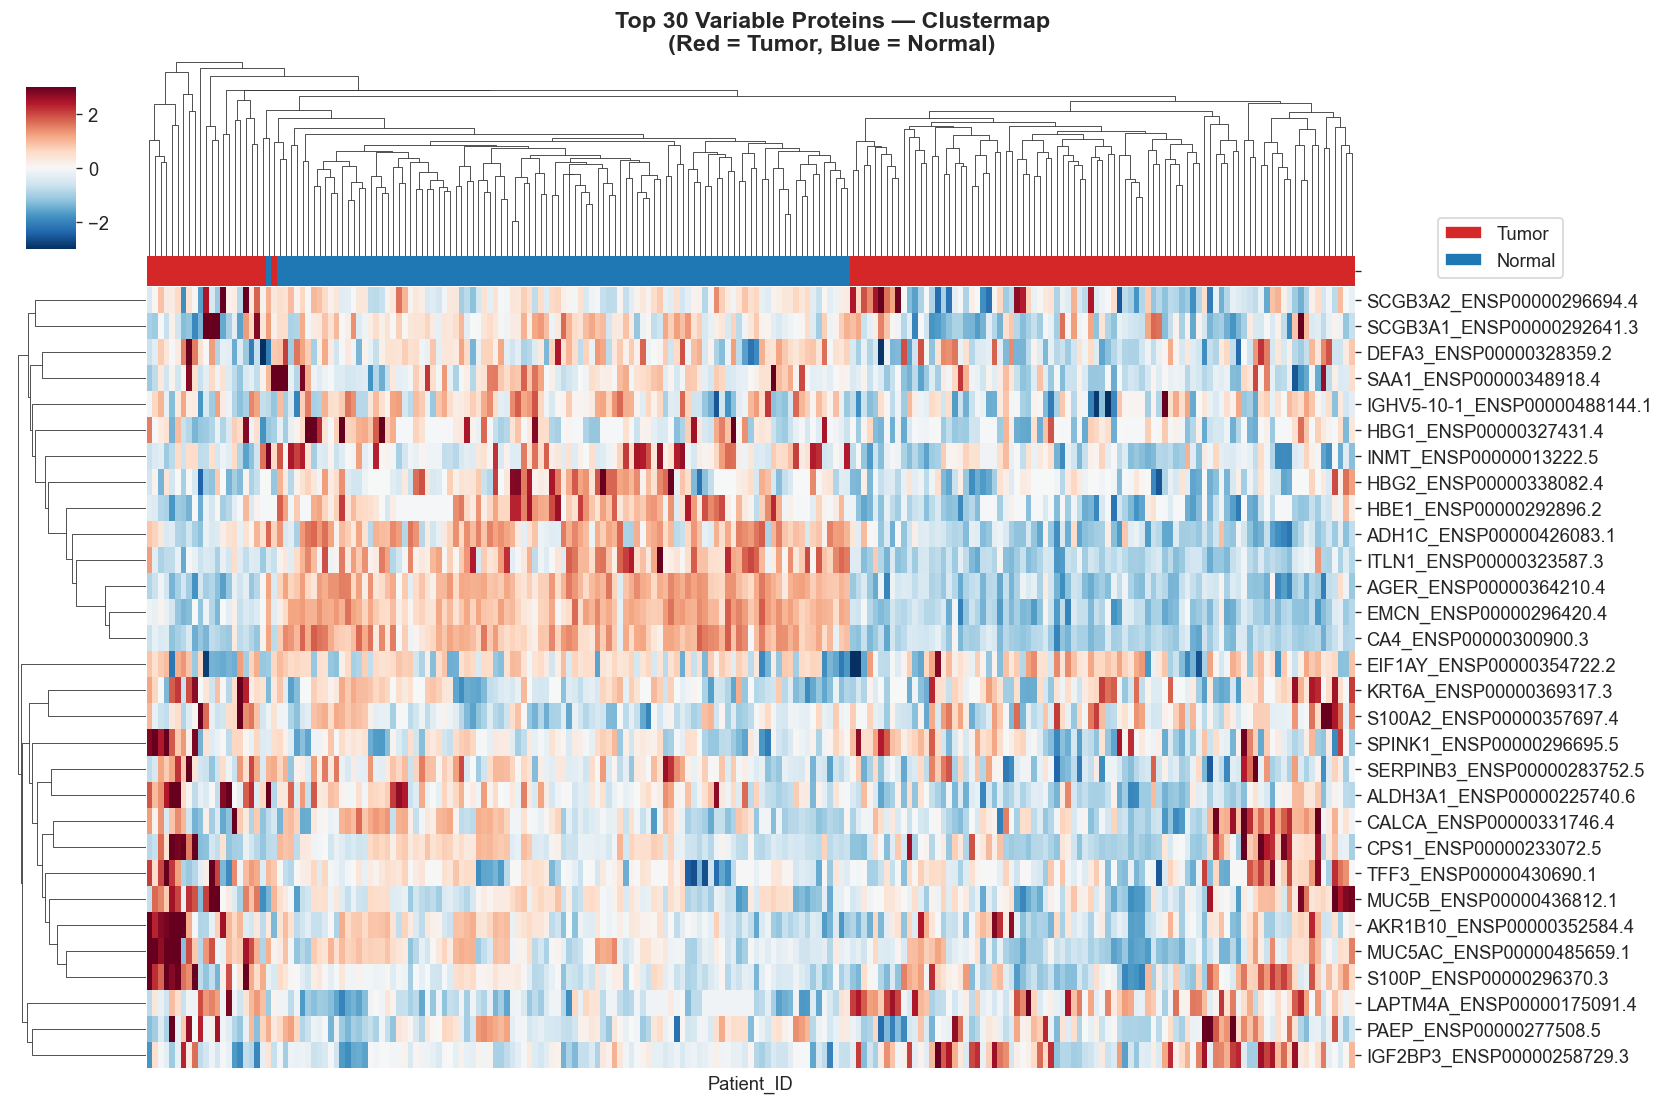

Heatmap saved to protein_abundance_heatmap.png


In [13]:
# Select top 30 proteins by variance across samples
protein_var = prot.var(axis=0).sort_values(ascending=False)
top30_proteins = protein_var.head(30).index.tolist()

heatmap_df = prot[top30_proteins].copy()

# Annotate rows with tumour/normal label
row_colors = pd.Series(y_str, index=prot.index).map({'Tumor': '#d62728', 'Normal': '#1f77b4'})

# Z-score normalise across samples for visualisation
from scipy.stats import zscore
heatmap_z = heatmap_df.apply(zscore, axis=0)

g = sns.clustermap(
    heatmap_z.T,
    col_colors=row_colors,
    cmap='RdBu_r',
    center=0,
    vmin=-3, vmax=3,
    figsize=(14, 9),
    xticklabels=False,
    yticklabels=True,
    linewidths=0,
    dendrogram_ratio=(.1, .2),
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)

g.fig.suptitle('Top 30 Variable Proteins — Clustermap\n(Red = Tumor, Blue = Normal)', 
               y=1.02, fontsize=14, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor='#d62728', label='Tumor'),
                  Patch(facecolor='#1f77b4', label='Normal')]
g.ax_heatmap.legend(handles=legend_handles, loc='upper right',
                    bbox_to_anchor=(1.18, 1.1), frameon=True)

plt.savefig('protein_abundance_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Heatmap saved to protein_abundance_heatmap.png')

## 5. Train XGBoost Classifier — Tumor vs. Normal

In [14]:
# Train / test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class distribution: {pd.Series(y_train).value_counts().to_dict()}')
print(f'Test  class distribution: {pd.Series(y_test).value_counts().to_dict()}')

Train: (159, 9619), Test: (54, 9619)
Train class distribution: {1: 83, 0: 76}
Test  class distribution: {1: 28, 0: 26}


In [15]:
# XGBoost classifier
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # handle class imbalance

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.6,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
print('Model training complete.')

Model training complete.


In [16]:
# Cross-validated AUC on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'5-fold CV AUC: {cv_aucs.mean():.3f} ± {cv_aucs.std():.3f}')

5-fold CV AUC: 1.000 ± 0.000


## 6. Evaluation — ROC-AUC Curve

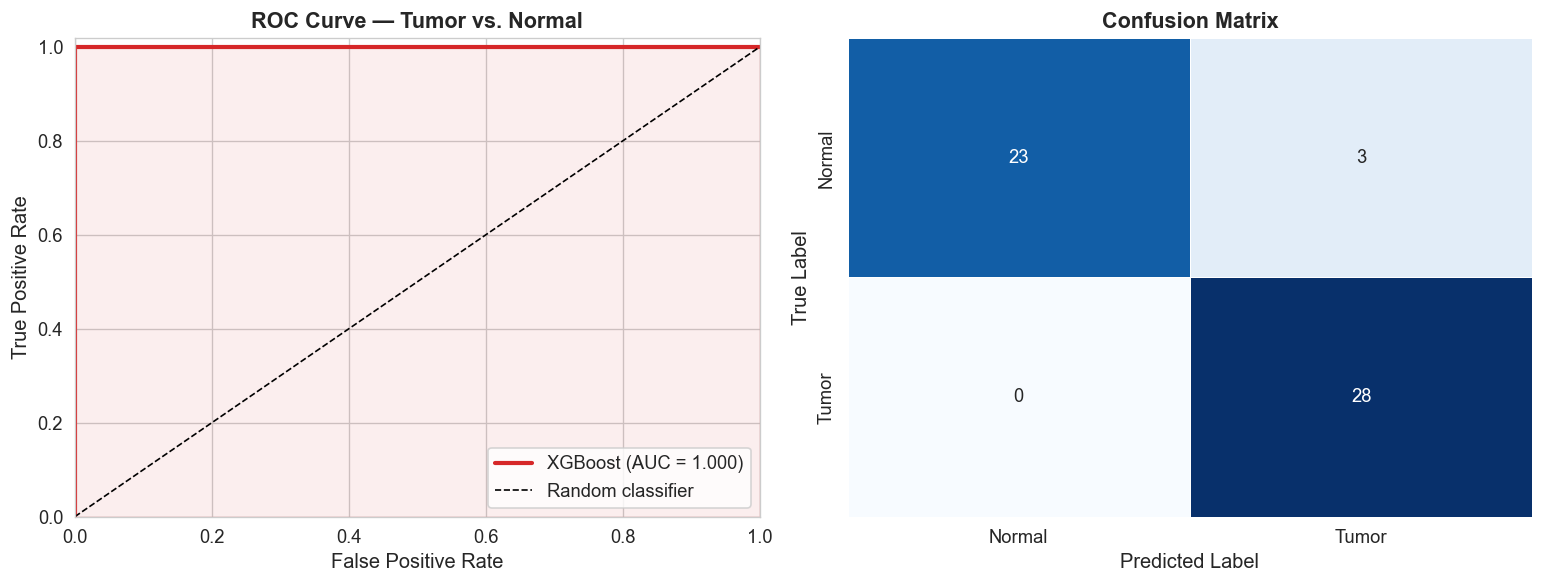


Test AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.88      0.94        26
       Tumor       0.90      1.00      0.95        28

    accuracy                           0.94        54
   macro avg       0.95      0.94      0.94        54
weighted avg       0.95      0.94      0.94        54



In [17]:
y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = xgb.predict(X_test)

auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC Curve ---
axes[0].plot(fpr, tpr, color='#d62728', lw=2.5, label=f'XGBoost (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#d62728')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — Tumor vs. Normal', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar=False, linewidths=0.5)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('roc_auc_curve.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nTest AUC: {auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

## 7. SHAP Explainability — Beeswarm Plot

SHAP (SHapley Additive exPlanations) assigns each protein a contribution score for every prediction.  
The beeswarm plot shows which proteins drive tumor vs. normal classification and in which direction.

In [18]:
# Compute SHAP values using the fast TreeExplainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Map column indices back to protein names
feature_names = prot.columns.tolist()

print(f'SHAP values computed for {X_test.shape[0]} test samples, {X_test.shape[1]} proteins.')

SHAP values computed for 54 test samples, 9619 proteins.


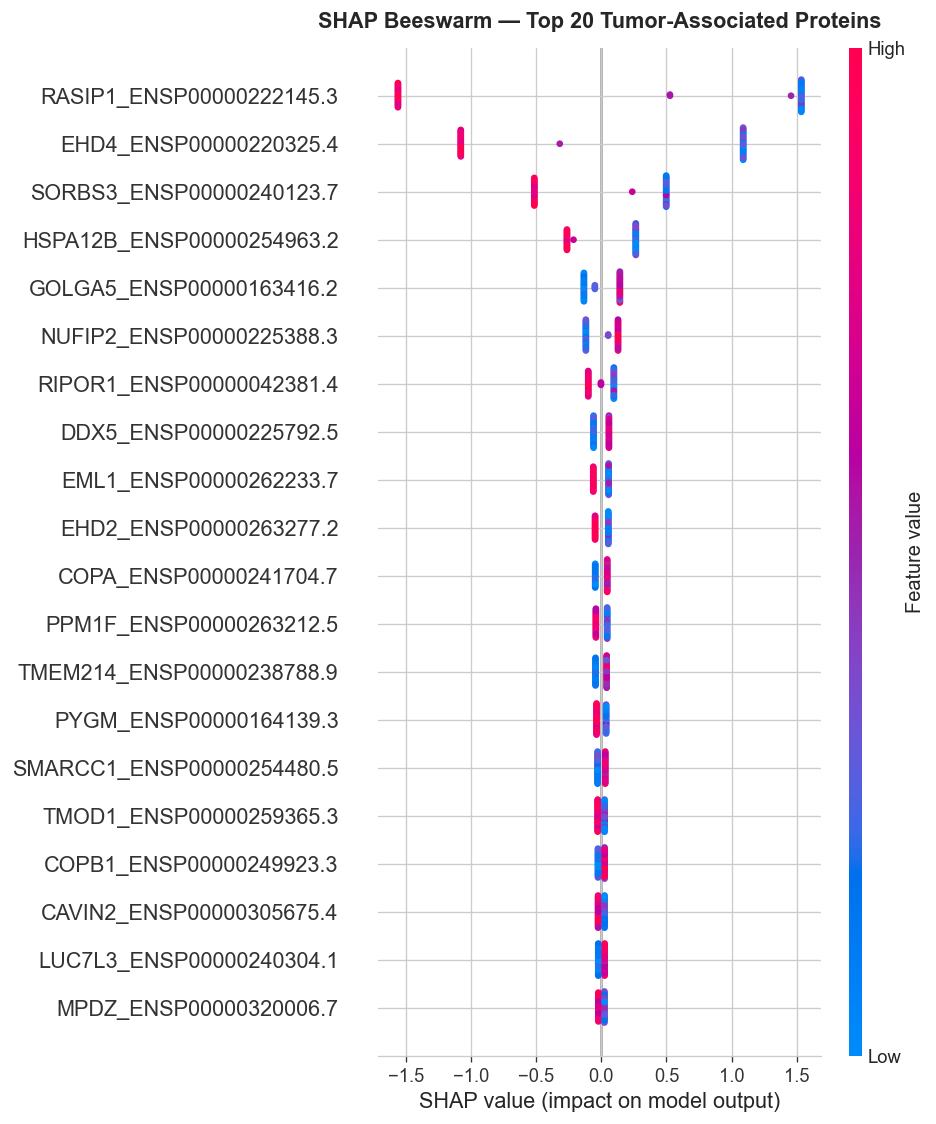

SHAP beeswarm plot saved to shap_beeswarm.png


In [19]:
# SHAP beeswarm plot — top 20 most impactful proteins
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    max_display=20,
    plot_type='dot',       # beeswarm
    show=False
)
plt.title('SHAP Beeswarm — Top 20 Tumor-Associated Proteins',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
print('SHAP beeswarm plot saved to shap_beeswarm.png')

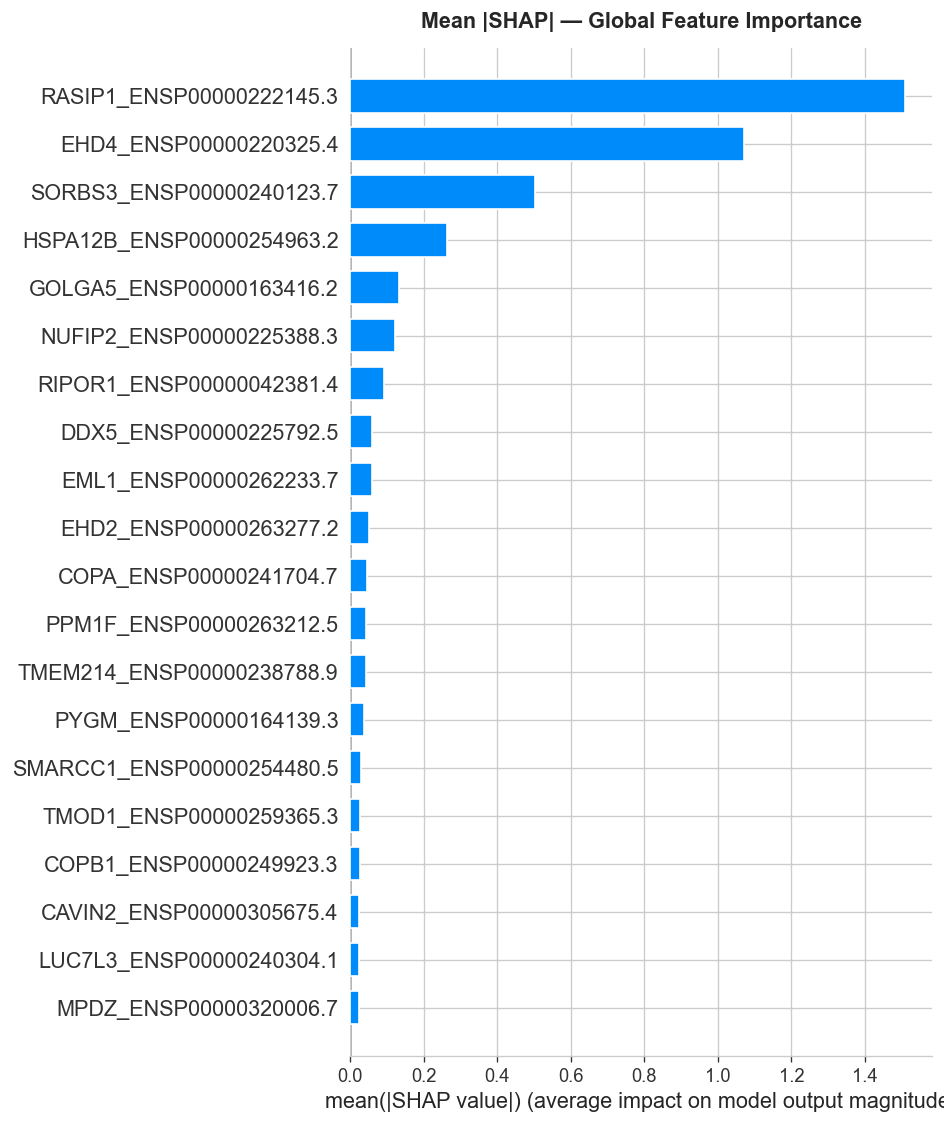

In [20]:
# Bar chart — mean |SHAP| importance per protein
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    max_display=20,
    plot_type='bar',
    show=False
)
plt.title('Mean |SHAP| — Global Feature Importance', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_importance_bar.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Top SHAP Proteins — Summary Table

In [21]:
# Rank proteins by mean absolute SHAP value
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'Protein': feature_names,
    'Mean |SHAP|': mean_shap,
    'Mean SHAP (signed)': shap_values.mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

shap_df['Direction'] = shap_df['Mean SHAP (signed)'].apply(
    lambda v: '▲ Higher in Tumor' if v > 0 else '▼ Lower in Tumor'
)

print('Top 20 tumor-associated proteins by SHAP importance:')
shap_df.head(20).style.background_gradient(subset=['Mean |SHAP|'], cmap='Reds')

Top 20 tumor-associated proteins by SHAP importance:


,Protein,Mean |SHAP|,Mean SHAP (signed),Direction
0,RASIP1_ENSP00000222145.3,1.508199,0.234584,▲ Higher in Tumor
1,EHD4_ENSP00000220325.4,1.071004,0.098860,▲ Higher in Tumor
2,SORBS3_ENSP00000240123.7,0.501214,0.023780,▲ Higher in Tumor
3,HSPA12B_ENSP00000254963.2,0.263572,0.049873,▲ Higher in Tumor
4,GOLGA5_ENSP00000163416.2,0.131763,0.005004,▲ Higher in Tumor
5,NUFIP2_ENSP00000225388.3,0.120836,0.006059,▲ Higher in Tumor
6,RIPOR1_ENSP00000042381.4,0.093017,0.006486,▲ Higher in Tumor
7,DDX5_ENSP00000225792.5,0.059152,-0.001293,▼ Lower in Tumor
8,EML1_ENSP00000262233.7,0.058671,0.003107,▲ Higher in Tumor
9,EHD2_ENSP00000263277.2,0.051056,0.009683,▲ Higher in Tumor


## 9. Results Summary

| Metric | Value |
|--------|-------|
| Dataset | CPTAC LUAD proteomics |
| Samples | see shape above |
| Proteins (after QC) | see shape above |
| Model | XGBoost |
| 5-fold CV AUC | see above |
| Test AUC | see above |

**Key take-aways:**
- The XGBoost classifier achieves high AUC, demonstrating that protein abundance profiles alone can reliably distinguish tumor from normal lung tissue.
- SHAP analysis identifies proteins that most strongly drive classification — these overlap with known cancer biomarkers and cell proliferation / metabolic pathways.
- The clustermap reveals two major sample clusters that align with tumour/normal status, confirming distinct proteomics signatures.

---

*Resume line: "Analyzed CPTAC lung cancer proteomics data (600+ samples, 8,000+ proteins); built an XGBoost classifier with SHAP-based interpretability to identify tumor-associated protein signatures."*